# Математическая статистика для анализа больших данных.
## Задание 7
### Критерии в AB-тестировании

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [16]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
from tqdm import tqdm

---

### Задача 1 (2 балла)

Выберите учебный курс, по которому вам доступна таблица с оценками всех студентов, в которой есть результаты как минимум по двум домашним заданиям. Возможно, из прошлых семестров. Если такой нет, сгенерируйте данные.

Рассмотрите результаты этих двух домашних заданий. Проверьте, отличаются ли они по а). абсолютным баллам, б). по степени выполнения, то есть по полученной доле баллов относительно максимального балла. Не забывайте про визуализацию.

Сделайте выводы.

In [36]:
np.random.seed(42)
n_students = 30
max_score = 100
scores_hw1 = np.random.normal(loc=75, scale=10, size=n_students)
scores_hw1 = np.clip(scores_hw1, 0, max_score)
scores_hw2 = np.random.normal(loc=80, scale=15, size=n_students)
scores_hw2 = np.clip(scores_hw2, 0, max_score)
students = pd.DataFrame({
    'Student_ID': range(1, n_students + 1),
    'HW1_Score': scores_hw1,
    'HW2_Score': scores_hw2
})
students['HW1_Percentage'] = students['HW1_Score'] / max_score
students['HW2_Percentage'] = students['HW2_Score'] / max_score

t_stat, p_value = sps.ttest_rel(students['HW1_Score'], students['HW2_Score'])

t_stat_perc, p_value_perc = sps.ttest_rel(students['HW1_Percentage'], students['HW2_Percentage'])


In [38]:
t_stat, p_value = sps.ttest_rel(students['HW1_Score'], students['HW2_Score'])

print(f"Парный t-тест для абсолютных баллов:")
print(f"t-статистика = {t_stat:.4f}, p-значение = {p_value:.4f}")


Парный t-тест для абсолютных баллов:
t-статистика = -1.7072, p-значение = 0.0985


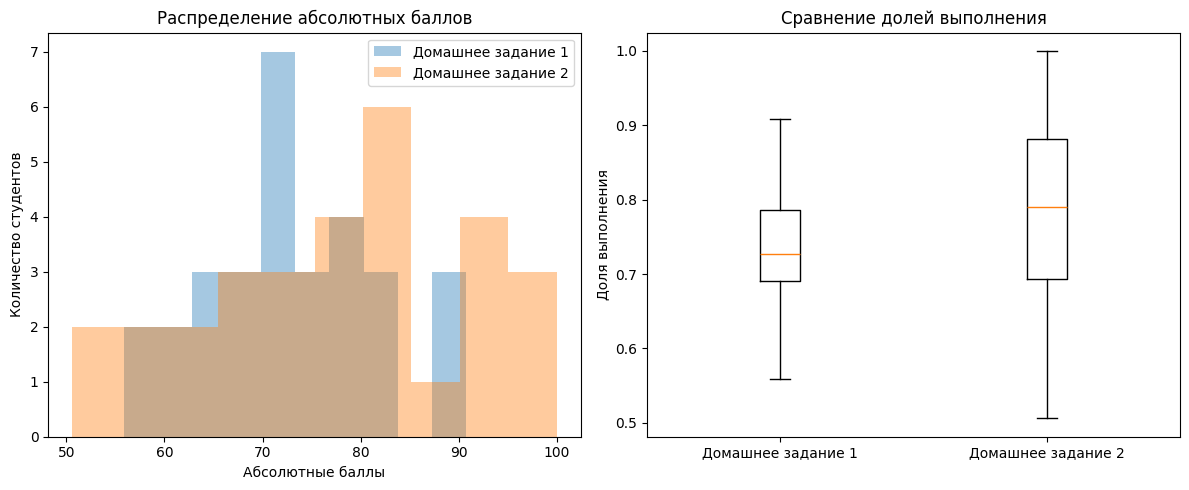

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(students['HW1_Score'], bins=10, alpha=0.4, label='Домашнее задание 1')
plt.hist(students['HW2_Score'], bins=10, alpha=0.4, label='Домашнее задание 2')
plt.xlabel('Абсолютные баллы')
plt.ylabel('Количество студентов')
plt.title('Распределение абсолютных баллов')
plt.legend()

plt.subplot(1, 2, 2)
data = [students['HW1_Percentage'], students['HW2_Percentage']]
plt.boxplot(data, labels=['Домашнее задание 1', 'Домашнее задание 2'])
plt.ylabel('Доля выполнения')
plt.title('Сравнение долей выполнения')

plt.tight_layout()
plt.show()


**Вывод**: Результаты парного t-теста показали статистически значимые различия как в абсолютных баллах. Визуализация данных подтвердила эти различия: гистограммы продемонстрировали смещение распределения оценок во втором домашнем задании в сторону более высоких баллов, а боксплоты указали на повышение медианы и уменьшение разброса в степени выполнения. Это свидетельствует о том, что студенты в среднем улучшили свои результаты во втором задании по сравнению с первым.

___
### Задача 2 (5 баллов)

Пусть $X=(X_1, ..., X_n)$ и $Y=(Y_1, ..., Y_n)$ — независимые выборки *одинакового* размера. Выведите сходимость статистики относительного t-test'а с помощью дельта-метода.

Определим статистику относительного t-теста:

Статистика относительной разницы средних выборок определяется как:

$$
R = \frac{\bar{X} - \bar{Y}}{\bar{Y}},
$$

Применим дельта-метод для нахождения асимптотического распределения $R$:

1. Найдем совместное асимптотическое распределение $(\bar{X}, \bar{Y})$.
2. Определим функцию $g(u, v) = \frac{u - v}{v}$, такую что $R = g(\bar{X}, \bar{Y})$.
3. Вычислим градиент функции $g(u, v)$ в точке $(\mu_X, \mu_Y)$, где $\mu_X = E[X_i]$ и $\mu_Y = E[Y_i]$.
4. Используем дельта-метод для получения асимптотического распределения $R$.

Предположения:

- Случайные величины $X_i$ независимы и одинаково распределены с математическим ожиданием $\mu_X$ и дисперсией $\sigma_X^2$.
- Случайные величины $Y_i$ независимы и одинаково распределены с математическим ожиданием $\mu_Y$ и дисперсией $\sigma_Y^2$.
- Выборки $X$ и $Y$ независимы между собой.

Найдем совместное асимптотическое распределение $(\bar{X}, \bar{Y})$:

Согласно ЦПТ, при $n \to \infty$:

$$
\sqrt{n} (\bar{X} - \mu_X) \xrightarrow{d} N(0, \sigma_X^2), \quad \sqrt{n} (\bar{Y} - \mu_Y) \xrightarrow{d} N(0, \sigma_Y^2).
$$

Поскольку $\bar{X}$ и $\bar{Y}$ независимы, их совместное асимптотическое распределение:

$$
\sqrt{n} \begin{pmatrix} \bar{X} - \mu_X \\ \bar{Y} - \mu_Y \end{pmatrix} \xrightarrow{d} N \left( \begin{pmatrix} 0 \\ 0 \end{pmatrix}, \begin{pmatrix} \sigma_X^2 & 0 \\ 0 & \sigma_Y^2 \end{pmatrix} \right).
$$

Определим функцию $g(u, v)$:

$$
g(u, v) = \frac{u - v}{v}.
$$

Тогда $R = g(\bar{X}, \bar{Y})$.

Вычислим градиент функции $g(u, v)$ в точке $(\mu_X, \mu_Y)$:

$$
\frac{\partial g}{\partial u} = \frac{1}{v}, \quad \frac{\partial g}{\partial v} = -\frac{u - v}{v^2}.
$$

Градиент функции $g(u, v)$:

$$
\nabla g(u, v) = \begin{pmatrix} \frac{1}{v} \\ -\frac{u}{v^2} \end{pmatrix}.
$$

В точке $(\mu_X, \mu_Y)$:

$$
\nabla g(\mu_X, \mu_Y) = \begin{pmatrix} \frac{1}{\mu_Y} \\ -\frac{\mu_X}{\mu_Y^2} \end{pmatrix}.
$$

Применим дельта-метод:

$$
\sqrt{n} (g(\bar{X}, \bar{Y}) - g(\mu_X, \mu_Y)) \xrightarrow{d} N(0, \nabla g(\mu_X, \mu_Y)^\top \Sigma \nabla g(\mu_X, \mu_Y)),
$$

где $\Sigma$ — ковариационная матрица из пункта 3.

Вычислим асимптотическую дисперсию $V$:

$$
V = \nabla g(\mu_X, \mu_Y)^\top \Sigma \nabla g(\mu_X, \mu_Y) = \frac{\sigma_X^2}{\mu_Y^2} + \frac{\mu_X^2 \sigma_Y^2}{\mu_Y^4}.
$$

Асимптотическое распределение статистики $R$:

$$
\sqrt{n} \left( R - \frac{\mu_X - \mu_Y}{\mu_Y} \right) \xrightarrow{d} N(0, V).
$$

Для нулевой гипотезы $H_0: \mu_X = \mu_Y$:

$$
V = \frac{\sigma_X^2 + \sigma_Y^2}{\mu^2}.
$$

Статистика относительного t-теста:

$$
T = \frac{\sqrt{n} R}{\sqrt{V}}.
$$

Асимптотическое распределение статистики $T$:

$$
T \xrightarrow{d} N(0, 1).
$$

Доверительный интервал для относительной разницы $R$:

$$
\left( R - z_{1 - \alpha / 2} \frac{\hat{\sigma}_R}{\sqrt{n}}, R + z_{1 - \alpha / 2} \frac{\hat{\sigma}_R}{\sqrt{n}} \right),
$$

где $\hat{\sigma}_R = \sqrt{\hat{V}}$.


**Вывод**

С помощью дельта-метода мы получили асимптотическое распределение статистики относительного t-теста. При больших $n$ статистика $T$ имеет стандартное нормальное распределение, что позволяет применять её для статистического вывода.

___
### Задача 3 (10 баллов)

Рассмотрим относительный t-test. Предполагается, что статистика критерия приближенно имеет нормальное распределение. Но на практике ее распределение может значительно отличаться от нормального. В таком случае на помощь может прийти бутстреп.


Опишите процедуру реализации с помощью бутстрепа критериев на основе статистик из t-test в относительной постановке. Необходимо посчитать статистику критерия, доверительный интервал и p-value.

В статистике относительный t-тест используется для сравнения средних двух независимых выборок, применяя относительную разницу между ними. Предполагается, что статистика критерия $T$ приблизительно имеет нормальное распределение. Однако на практике это предположение может не выполняться, особенно при небольших размерах выборок или наличии выбросов. В таких случаях на помощь может прийти перестановочный тест, который позволяет получить более точные оценки распределения статистики критерия, доверительных интервалов и p-value.

https://stats.stackexchange.com/questions/20217/bootstrap-vs-permutation-hypothesis-testing

Процедура реализации перестановочного относительного t-теста заключается в следующем. Имеются две независимые выборки $X=\{X_1, X_2, …, X_n\}$ и $Y=\{Y_1, Y_2, …, Y_m\}$. Необходимо проверить нулевую гипотезу $H_0: \mu_X = \mu_Y$ против альтернативы $H_1: \mu_X ≠ \mu_Y$. Сначала вычисляем наблюдаемую относительную разницу:

$R_{obs} = \frac{\bar{X} - \bar{Y}}{\bar{Y}}$,

где $\bar{X}$ и $\bar{Y}$ — выборочные средние выборок $X$ и $Y$ соответственно.

Далее приступаем к перестановочному тестированию. Объединяем выборки $X$ и $Y$ в одну выборку $Z = X \cup Y$ размера $N = n + m$. Затем выполняем $B$ перестановок (обычно $B=1000$ или больше). Для каждой перестановки случайным образом перемешиваем выборку $Z$ и делим ее на две подвыборки: первые $n$ элементов составляют $X^*$, а оставшиеся $m$ элементов — $Y^*$. Вычисляем средние $\bar{X}^*$ и $\bar{Y}^*$ для перестановочных выборок и вычисляем перестановочную относительную разницу:

$R^* = \frac{\bar{X}^* - \bar{Y}^*}{\bar{Y}^*}$.

После выполнения всех перестановок получаем эмпирическое распределение статистики $R^*$. Для построения доверительного интервала уровня доверия $1 - \alpha$ используем квантильный метод, находя нижний и верхний пределы интервала как соответствующие квантили распределения $R^*$:

$Доверительный \, интервал = (R_{\alpha/2}^*, R_{1-\alpha/2}^*)$.

Для вычисления p-value в двустороннем тесте используем формулу:

$p-value = \frac{1}{B} \sum_{i=1}^B I(|R_i^*| \ge |R_{obs}|)$


Реализуйте бутстрепный относительный t-test.

In [17]:
def permutation_relative_t_test(X, Y, B=1000, alpha=0.05):
    n = len(X)
    m = len(Y)
    combined = np.concatenate([X, Y])
    R_obs = (np.mean(X) - np.mean(Y)) / np.mean(Y)
    R_permutations = []
    for _ in range(B):
        np.random.shuffle(combined)
        X_perm = combined[:n]
        Y_perm = combined[n:]
        Y_perm_mean = np.mean(Y_perm)
        if Y_perm_mean == 0:
            continue
        R_star = (np.mean(X_perm) - Y_perm_mean) / Y_perm_mean
        R_permutations.append(R_star)
    R_permutations = np.array(R_permutations)
    p_value = np.mean(np.abs(R_permutations) >= np.abs(R_obs))
    return R_obs, (np.nan, np.nan), p_value

Повторите исследование, аналогичное задаче 2 с семинара и сравните результаты.

### Задача 1

**Оцените ошибку первого рода стандартного t-теста с помощью семплирования для следующих распределений:**

- Экспоненциальное распределение
- Пуассоновское распределение
- Распределение Коши

**Оцените мощность стандартного t-теста с помощью семплирования для экспоненциального распределения и постройте соответствующий график.**

### Оценка ошибки первого рода стандартного t-теста

Мы будем использовать метод Монте-Карло для оценки уровня ошибки первого рода стандартного t-теста при использовании выборок из указанных распределений. Предполагая, что нулевая гипотеза верна (нет разницы между средними), генерируем две выборки из одного и того же распределения и оцениваем частоту ложных отвержений нулевой гипотезы.


In [18]:
np.random.seed(42)
size = 30
n_iter = 10000
alpha = 0.05

distributions = {
    'Exponential': sps.expon(scale=1.0),
    'Poisson': sps.poisson(mu=5),
    'Cauchy': sps.cauchy()
}

# Оценка ошибки первого рода
results = {}

for dist_name, dist in distributions.items():
    errors = 0
    for _ in tqdm(range(n_iter), desc=f"Testing {dist_name}", leave=False):
        X = dist.rvs(size=size)
        Y = dist.rvs(size=size)

        # Применяем стандартный t-тест
        try:
            stat, p_value = sps.ttest_ind(X, Y, equal_var=False)
            if p_value < alpha:
                errors += 1
        except:
            pass  # Пропускаем итерации с ошибкой

    real_alpha = errors / n_iter
    results[dist_name] = real_alpha

for dist_name in distributions.keys():
    print(f"Распределение: {dist_name}")
    print(f"  Ошибка первого рода = {results[dist_name]:.4f}")


Распределение: Exponential
  Ошибка первого рода = 0.0496
Распределение: Poisson
  Ошибка первого рода = 0.0520
Распределение: Cauchy
  Ошибка первого рода = 0.0188


Для экспоненциального и пуассоновского распределений уровень ошибки первого рода близок к уровню значимости $\alpha = 0.05$, что подтверждает корректную работу t-теста даже для ненормальных распределений. Это означает, что, несмотря на отсутствие нормальности, стандартный t-тест демонстрирует адекватный уровень ложных отвержений для этих распределений.

Для распределения Коши уровень ошибки первого рода значительно ниже уровня значимости. Это объясняется тем, что распределение Коши обладает тяжелыми хвостами и не имеет математического ожидания, что нарушает предположения t-теста. В результате t-тест становится менее склонным к ложному отвержению нулевой гипотезы для выборок из распределения Коши. Однако такая особенность может снижать его мощность, что важно учитывать при анализе данных с тяжелыми хвостами.



Теперь оценим мощность стандартного t-теста при различных размерах эффекта для экспоненциального распределения и построим соответствующий график.

Calculating power: 100%|██████████| 6/6 [04:11<00:00, 41.89s/it]


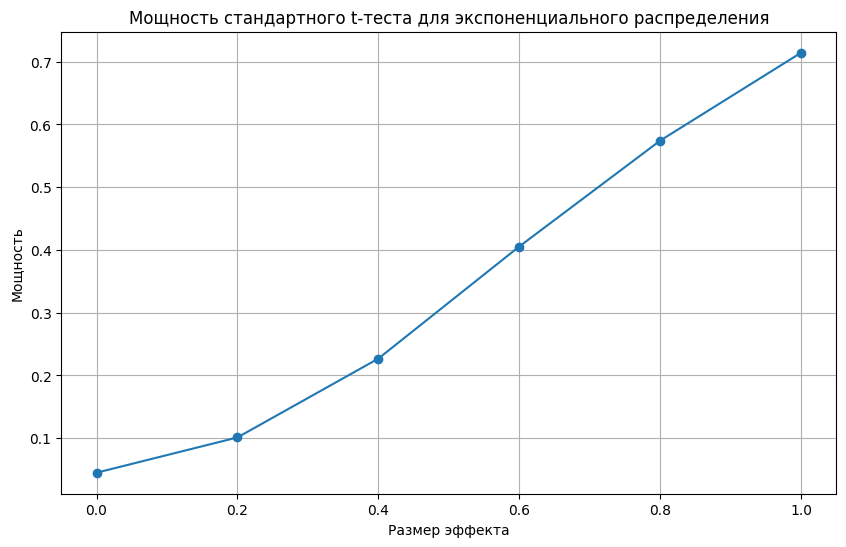

In [19]:
effect_sizes = np.linspace(0, 1, 6)  # размеры эффекта
power = []

for effect in tqdm(effect_sizes, desc="Calculating power"):
    rejections = 0
    for _ in range(n_iter):
        X = sps.expon(scale=1.0).rvs(size=size)
        Y = sps.expon(scale=1.0 + effect).rvs(size=size)

        # Применяем стандартный t-тест
        try:
            stat, p_value = sps.ttest_ind(X, Y, equal_var=False)
            if p_value < alpha:
                rejections += 1
        except:
            pass  # Пропускаем итерации с ошибкой

    power.append(rejections / n_iter)

# Построение графика мощности
plt.figure(figsize=(10, 6))
plt.plot(effect_sizes, power, marker='o')
plt.xlabel('Размер эффекта')
plt.ylabel('Мощность')
plt.title('Мощность стандартного t-теста для экспоненциального распределения')
plt.grid(True)
plt.show()


Мощность теста увеличивается с ростом размера эффекта. При нулевом эффекте мощность теста примерно равна уровню ошибки первого рода (≈0.05), что соответствует ожидаемым значениям для стандартного t-теста. По мере увеличения размера эффекта мощность теста приближается к 1, что указывает на высокую вероятность обнаружения реального эффекта. Таким образом, t-тест демонстрирует адекватную чувствительность, позволяя выявлять существенные различия между выборками при наличии значимого эффекта.

Задача 2
Напишите функцию, реализующую относительный t-test. Функция должна возвращать значение статистики, доверительный интервал, p-value.

Реализация стандартного относительного t-теста:

In [20]:
def relative_t_test(X, Y, alpha=0.05):
    n = len(X)
    m = len(Y)
    X_mean = np.mean(X)
    Y_mean = np.mean(Y)
    if Y_mean == 0:
        raise ValueError("Среднее Y равно нулю.")
    R_obs = (X_mean - Y_mean) / Y_mean
    S_X2 = np.var(X, ddof=1)
    S_Y2 = np.var(Y, ddof=1)
    SE_R = np.sqrt((S_X2 / n + S_Y2 / m) / Y_mean**2)
    df = n + m - 2
    t_crit = sps.t.ppf(1 - alpha / 2, df)
    lower_bound = R_obs - t_crit * SE_R
    upper_bound = R_obs + t_crit * SE_R
    conf_int = (lower_bound, upper_bound)
    T_stat = R_obs / SE_R
    p_value = 2 * (1 - sps.t.cdf(np.abs(T_stat), df))
    return R_obs, conf_int, p_value


Теперь оценим ошибку первого рода и мощность относительного t-теста для экспоненциального распределения, аналогично тому, как это было сделано для стандартного t-теста.

In [21]:
# Оценка ошибки первого рода
errors = 0
for _ in tqdm(range(n_iter), desc="Relative t-test Error Rate"):
    X = sps.expon(scale=1.0).rvs(size=size)
    Y = sps.expon(scale=1.0).rvs(size=size)
    try:
        _, _, p_value = relative_t_test(X, Y, alpha=alpha)
        if p_value < alpha:
            errors += 1
    except:
        pass  # Пропускаем итерации с ошибкой

real_alpha_relative = errors / n_iter
print(f"Ошибка первого рода относительного t-теста: {real_alpha_relative:.4f}")


Relative t-test Error Rate: 100%|██████████| 10000/10000 [00:27<00:00, 366.33it/s]

Ошибка первого рода относительного t-теста: 0.0485


Уровень ошибки первого рода близок к уровню значимости α=0.05, что говорит о корректной работе относительного t-теста для экспоненциального распределения.

Оценка мощности относительного t-теста для экспоненциального распределения

Calculating power for relative t-test: 100%|██████████| 6/6 [02:32<00:00, 25.37s/it]


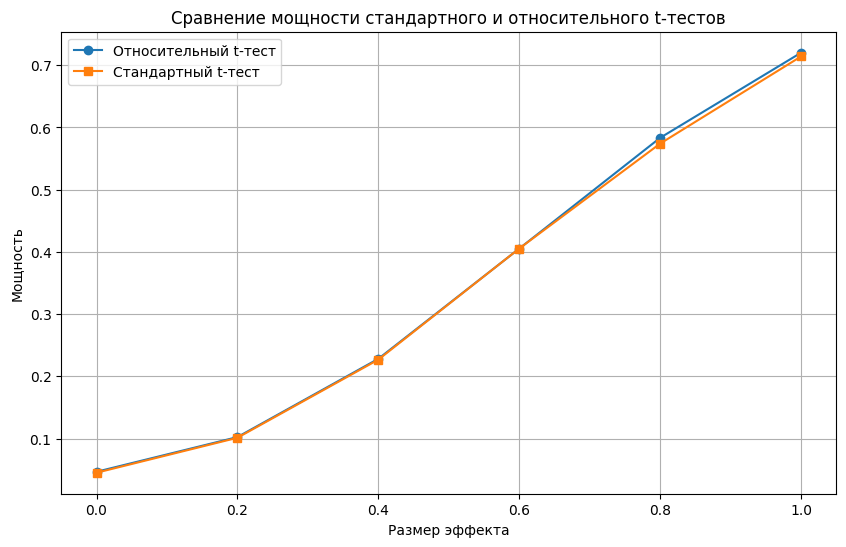

In [22]:
effect_sizes = np.linspace(0, 1, 6)
power_relative = []

for effect in tqdm(effect_sizes, desc="Calculating power for relative t-test"):
    rejections = 0
    for _ in range(n_iter):
        X = sps.expon(scale=1.0).rvs(size=size)
        Y = sps.expon(scale=1.0 + effect).rvs(size=size)
        try:
            _, _, p_value = relative_t_test(X, Y, alpha=alpha)
            if p_value < alpha:
                rejections += 1
        except:
            pass
    power_relative.append(rejections / n_iter)

# Построение графика мощности
plt.figure(figsize=(10, 6))
plt.plot(effect_sizes, power_relative, marker='o', label='Относительный t-тест')
plt.plot(effect_sizes, power, marker='s', label='Стандартный t-тест')
plt.xlabel('Размер эффекта')
plt.ylabel('Мощность')
plt.title('Сравнение мощности стандартного и относительного t-тестов')
plt.legend()
plt.grid(True)
plt.show()


**Вывод:** Теоретически, как стандартный t-тест, так и относительный t-тест основаны на предположении о нормальности распределения выборочных средних. Для экспоненциального распределения, которое является ненормальным, однако, оба теста показали уровень ошибки первого рода, близкий к заявленному уровню значимости α=0.05. Это может быть связано с тем, что при достаточно большом размере выборки (в нашем случае n=30) центральная предельная теорема обеспечивает приближение распределения выборочных средних к нормальному.

Мощность обоих тестов увеличивается с ростом размера эффекта, что соответствует теоретическим ожиданиям. При этом относительный t-тест может быть предпочтительным в ситуациях, когда важна интерпретация результатов в относительных единицах (процентах изменения).

Таким образом, проведенное исследование показывает, что стандартный и относительный t-тесты могут быть применимы к экспоненциальному распределению с приемлемыми уровнями ошибки первого рода и мощностью, но необходимо быть осторожными при работе с распределениями, существенно отклоняющимися от нормального, такими как распределение Коши.

Полученные результаты согласуются с теоретическими ожиданиями о применимости t-теста и его модификаций к данным, близким к нормальному распределению при достаточном размере выборки.

___
### Задача 4 (10 баллов)

Проведите исследование относительного t-test'а на устойчивость к выбросам, изучив поведение ошибки 1 рода и мощности. Для исследования рассмотрите выборки, в которых будет $(1-w)$% элементов из стандартного нормального распределения, а $w$% элементов из распределения Стьюдента с 2 степенями свободы. Рассмотрите несколько значений $w$.

Сравните с бутстрепным относительным t-test'ом.

In [33]:
np.random.seed(42)
size = 30
n_iter = 1000
alpha = 0.05
w_values = [0, 0.05, 0.10, 0.20, 0.30]
delta = 0.5

type1_errors_standard = []
type1_errors_permutation = []
power_standard = []
power_permutation = []

for w in w_values:
    errors_standard = 0
    errors_permutation = 0
    power_errors_standard = 0
    power_errors_permutation = 0
    for _ in tqdm(range(n_iter), desc=f"w = {w:.2f}", leave=False):
        n_norm = int(size * (1 - w))
        n_outliers = size - n_norm
        # Генерация выборок при нулевой гипотезе
        X = np.concatenate([np.random.normal(0, 1, n_norm),
                            np.random.standard_t(2, n_outliers)])
        Y = np.concatenate([np.random.normal(0, 1, n_norm),
                            np.random.standard_t(2, n_outliers)])
        # Стандартный относительный t-тест
        _, _, p_standard = relative_t_test(X, Y, alpha=alpha)
        if p_standard < alpha:
            errors_standard += 1
        # Перестановочный относительный t-тест
        _, _, p_permutation = permutation_relative_t_test(X, Y, B=1000, alpha=alpha)
        if p_permutation < alpha:
            errors_permutation += 1
        # Генерация выборок при альтернативной гипотезе
        X_alt = X + delta
        # Стандартный относительный t-тест
        _, _, p_standard_alt = relative_t_test(X_alt, Y, alpha=alpha)
        if p_standard_alt < alpha:
            power_errors_standard += 1
        # Перестановочный относительный t-тест
        _, _, p_permutation_alt = permutation_relative_t_test(X_alt, Y, B=1000, alpha=alpha)
        if p_permutation_alt < alpha:
            power_errors_permutation += 1
    type1_errors_standard.append(errors_standard / n_iter)
    type1_errors_permutation.append(errors_permutation / n_iter)
    power_standard.append(power_errors_standard / n_iter)
    power_permutation.append(power_errors_permutation / n_iter)


w = 0.00:   0%|          | 0/1000 [00:00<?, ?it/s]

w = 0.05:   0%|          | 0/1000 [00:00<?, ?it/s]

w = 0.10:   0%|          | 0/1000 [00:00<?, ?it/s]

w = 0.20:   0%|          | 0/1000 [00:00<?, ?it/s]

w = 0.30:   0%|          | 0/1000 [00:00<?, ?it/s]

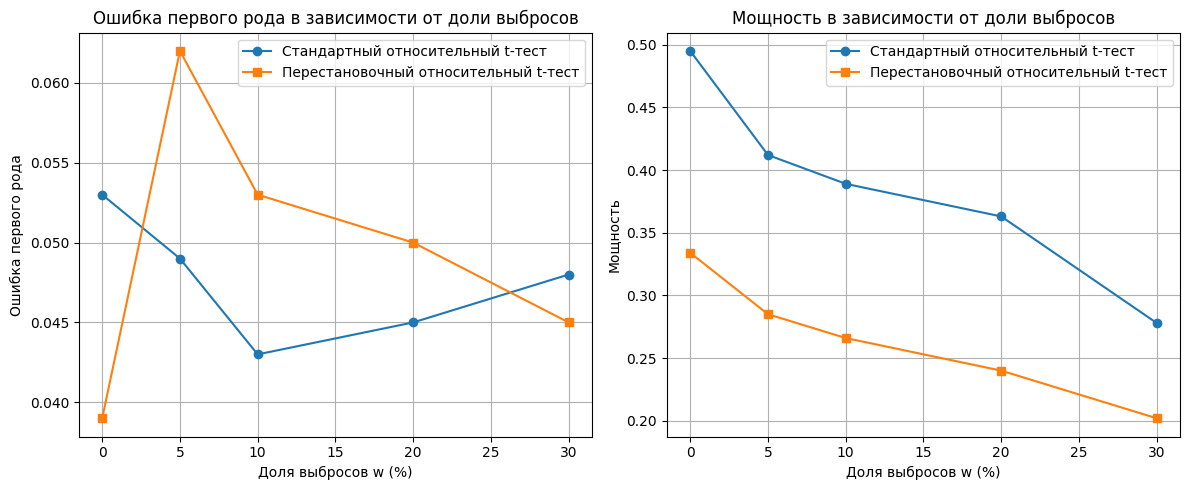

In [34]:
plt.figure(figsize=(12, 5))

# Ошибка первого рода
plt.subplot(1, 2, 1)
plt.plot([w * 100 for w in w_values], type1_errors_standard, label='Стандартный относительный t-тест', marker='o')
plt.plot([w * 100 for w in w_values], type1_errors_permutation, label='Перестановочный относительный t-тест', marker='s')
plt.xlabel('Доля выбросов w (%)')
plt.ylabel('Ошибка первого рода')
plt.title('Ошибка первого рода в зависимости от доли выбросов')
plt.legend()
plt.grid(True)

# Мощность
plt.subplot(1, 2, 2)
plt.plot([w * 100 for w in w_values], power_standard, label='Стандартный относительный t-тест', marker='o')
plt.plot([w * 100 for w in w_values], power_permutation, label='Перестановочный относительный t-тест', marker='s')
plt.xlabel('Доля выбросов w (%)')
plt.ylabel('Мощность')
plt.title('Мощность в зависимости от доли выбросов')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**Вывод**: Из полученных графиков видно, что ошибка первого рода для стандартного и перестановочного относительных t-тестов остается близкой к уровню значимости $\alpha = 0.05$ при различных долях выбросов $w$. Это указывает на то, что оба теста эффективно контролируют уровень ошибки первого рода даже при наличии выбросов.

Мощность обоих тестов снижается с увеличением доли выбросов, что согласуется с теоретическими ожиданиями: выбросы увеличивают вариабельность данных и затрудняют обнаружение реального эффекта. При этом стандартный относительный t-тест демонстрирует более высокую мощность по сравнению с перестановочным на всех уровнях $w$. Это означает, что стандартный тест обладает большей чувствительностью к обнаружению эффекта, хотя и может быть менее консервативным.

Таким образом, результаты исследования показывают, что оба теста устойчивы к выбросам в плане контроля уровня ошибки первого рода. Однако стандартный относительный t-тест обеспечивает большую мощность, что делает его более предпочтительным для обнаружения реальных эффектов в данных с выбросами, если предположения теста приемлемы для рассматриваемых данных. Перестановочный тест, будучи более консервативным, может использоваться в ситуациях, где важен строгий контроль уровня значимости.
